In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline_device = 0 if torch.cuda.is_available() else -1
print(f"Device: {device}")

# Готовая мультиязычная BERT-модель для sentiment classification.
MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

print("Model loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded: nlptown/bert-base-multilingual-uncased-sentiment
Tokenizer class: BertTokenizer
Model class: BertForSequenceClassification
Number of labels: 5
id2label: {0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


In [ ]:
def create_trainer(model, tokenizer, train_ds, eval_ds, fast_mode=True):
    # Настройка параметров в зависимости от режима
    if fast_mode:
        train_subset = train_ds.shuffle(seed=42).select(range(100))
        eval_subset = eval_ds.shuffle(seed=42).select(range(50))
        num_epochs = 1
        logging_steps = 5
    else:
        train_subset = train_ds
        eval_subset = eval_ds
        num_epochs = 2
        logging_steps = 100

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        logging_steps=logging_steps,
        report_to="none"
    )

    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=eval_subset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

In [ ]:
def predict_sentiment(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=-1).item()
    return model.config.id2label[predicted_class_id]

# Тестовые примеры
test_texts = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "The food was okay, but the service was quite slow.",
    "This is the worst experience I have ever had. Truly awful."
]

for text in test_texts:
    label = predict_sentiment(text, model, tokenizer, device)
    print(f"Text: {text}\nSentiment: {label}\n")

Text: This movie was absolutely fantastic! I loved every minute of it.
Sentiment: 5 stars

Text: The food was okay, but the service was quite slow.
Sentiment: 3 stars

Text: This is the worst experience I have ever had. Truly awful.
Sentiment: 1 star



In [ ]:
# Загружаем датасет 'emotion'
emotions = load_dataset('emotion')

# Показываем размеры split-частей
print("Dataset structure:")
print(emotions)

# Выводим 3-5 примеров текстов и меток
print("\nExamples from training set:")
train_ds = emotions['train']
for i in range(5):
    text = train_ds[i]['text']
    label_id = train_ds[i]['label']
    label_name = train_ds.features['label'].int2str(label_id)
    print(f"{i+1}. Text: {text[:80]}... | Label: {label_id} ({label_name})")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Examples from training set:
1. Text: i didnt feel humiliated... | Label: 0 (sadness)
2. Text: i can go from feeling so hopeless to so damned hopeful just from being around so... | Label: 0 (sadness)
3. Text: im grabbing a minute to post i feel greedy wrong... | Label: 3 (anger)
4. Text: i am ever feeling nostalgic about the fireplace i will know that it is still on ... | Label: 2 (love)
5. Text: i am feeling grouchy... | Label: 3 (anger)


### Описание датасета
Датасет **'emotion'** содержит твиты на английском языке, размеченные по шести базовым эмоциям:
- **0: sadness** (грусть)
- **1: joy** (радость)
- **2: love** (любовь)
- **3: anger** (гнев)
- **4: fear** (страх)
- **5: surprise** (удивление)

Цель классификации — определить преобладающую эмоцию в коротком текстовом сообщении.

### 2.3.4. Инференс готовой модели
На этом этапе мы берем 5 случайных примеров из тренировочной выборки и смотрим, какую оценку (в звездах) присваивает им модель BERT, обученная на отзывах.

In [ ]:
# Компактная демонстрация: от текста к тензорам
sample_text = "i feel humiliated"

# Кодируем текст
encoded = tokenizer(sample_text, add_special_tokens=True, return_tensors="pt")

# Подготовка данных для отображения
full_ids = encoded["input_ids"][0].tolist()
full_tokens = tokenizer.convert_ids_to_tokens(full_ids)

print(f"Исходный текст: {sample_text}")
print("\nРезультат токенизации:")
display(pd.DataFrame({
    "Token": full_tokens,
    "ID": full_ids,
    "Attention Mask": encoded["attention_mask"][0].tolist()
}).T)

print(f"\nФинальный тензор input_ids для модели:\n{encoded['input_ids']}")

Исходный текст: i feel humiliated

Результат токенизации:


,0,1,2,3,4,5,6
Token,[CLS],i,feel,hum,##ilia,##ted,[SEP]
ID,101,151,23333,52179,50524,11894,102
Attention Mask,1,1,1,1,1,1,1



Финальный тензор input_ids для модели:
tensor([[  101,   151, 23333, 52179, 50524, 11894,   102]])


In [ ]:
import pandas as pd

def inspect_single_text(text: str, tokenizer) -> pd.DataFrame:
    """Вспомогательная функция для табличного просмотра токенизации."""
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    decoded_pieces = [tokenizer.decode([tid]) for tid in token_ids]
    return pd.DataFrame(
        {
            "position": list(range(len(tokens))),
            "token": tokens,
            "token_id": token_ids,
            "decoded_piece": decoded_pieces,
        }
    )

# Выберем пример из нашего датасета
sample_text = emotions['train'][0]['text']
print(f"Исходный текст: {sample_text}")
display(inspect_single_text(sample_text, tokenizer))

Исходный текст: i didnt feel humiliated


,position,token,token_id,decoded_piece
0,0,i,151,i
1,1,didn,30557,didn
2,2,##t,10123,##t
3,3,feel,23333,feel
4,4,hum,52179,hum
5,5,##ilia,50524,##ilia
6,6,##ted,11894,##ted


In [ ]:
# 1. Анализ специальных токенов
special_tokens_df = pd.DataFrame(
    {
        "name": ["cls_token", "sep_token", "pad_token", "unk_token", "mask_token"],
        "token": [tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token, tokenizer.unk_token, tokenizer.mask_token],
        "token_id": [tokenizer.cls_token_id, tokenizer.sep_token_id, tokenizer.pad_token_id, tokenizer.unk_token_id, tokenizer.mask_token_id],
    }
)
print("Служебные токены токенизатора:")
display(special_tokens_df)

# 2. Полная структура входа (input_ids, attention_mask, token_type_ids)
encoded = tokenizer(
    sample_text,
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True
)

full_ids = encoded["input_ids"]
full_tokens = tokenizer.convert_ids_to_tokens(full_ids)

print("\nПолная последовательность с добавлением special tokens:")
display(pd.DataFrame({
    "token": full_tokens,
    "token_id": full_ids,
    "attention_mask": encoded["attention_mask"],
    "token_type_id": encoded["token_type_ids"]
}))

Служебные токены токенизатора:


,name,token,token_id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103



Полная последовательность с добавлением special tokens:


,token,token_id,attention_mask,token_type_id
0,[CLS],101,1,0
1,i,151,1,0
2,didn,30557,1,0
3,##t,10123,1,0
4,feel,23333,1,0
5,hum,52179,1,0
6,##ilia,50524,1,0
7,##ted,11894,1,0
8,[SEP],102,1,0


In [ ]:
# Демонстрация padding и truncation на батче текстов
short_text = "I feel happy."
long_text = "I am feeling very happy today because the sun is shining and everything is perfect. " * 10

batch_encoded = tokenizer(
    [short_text, long_text],
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

print("Форма тензора input_ids:", batch_encoded['input_ids'].shape)
print("\nПример с padding (первое предложение):")
print(batch_encoded['input_ids'][0])
print("\nПример с truncation (второе предложение обрезано до 20):")
print(batch_encoded['input_ids'][1])

Форма тензора input_ids: torch.Size([2, 20])

Пример с padding (первое предложение):
tensor([  101,   151, 23333, 19308,   119,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])

Пример с truncation (второе предложение обрезано до 20):
tensor([  101,   151, 10345, 35260, 12495, 19308, 13980, 12175, 10103, 13630,
        10127, 76416, 10110, 23225, 10127, 23021,   119,   151, 10345,   102])


In [ ]:
def get_sentiment_category(label_str):
    # Вспомогательная логика для интерпретации звезд
    stars = int(label_str.split()[0])
    if stars <= 2: return "Negative"
    if stars == 3: return "Neutral"
    return "Positive"

# Выбираем 5 примеров
samples = emotions['train'].select(range(10, 15))

results = []
for item in samples:
    text = item['text']
    true_label_id = item['label']
    true_label_name = emotions['train'].features['label'].int2str(true_label_id)

    # Инференс
    pred_label = predict_sentiment(text, model, tokenizer, device)
    pred_category = get_sentiment_category(pred_label)

    results.append({
        "Text": text[:100] + "...",
        "True Emotion": true_label_name,
        "Model Prediction": pred_label,
        "Interpretation": pred_category
    })

display(pd.DataFrame(results))

,Text,True Emotion,Model Prediction,Interpretation
0,i feel like i have to make the suffering i m s...,sadness,3 stars,Neutral
1,i do feel that running is a divine experience ...,joy,3 stars,Neutral
2,i think it s the easiest time of year to feel ...,anger,5 stars,Positive
3,i feel low energy i m just thirsty...,sadness,2 stars,Negative
4,i have immense sympathy with the general point...,joy,4 stars,Positive


### 2.3.5. Fine-tuning для классификации текста

На этом этапе мы перейдем от использования готовых предсказаний к обучению собственной головы классификатора поверх предобученного BERT.

In [ ]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import torch

# Переопределяем количество меток (6 эмоций)
NUM_LABELS = 6

# Загружаем модель с новой головой классификатора
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

print(f"Model {MODEL_NAME} initialized for {NUM_LABELS} classes.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model nlptown/bert-base-multilingual-uncased-sentiment initialized for 6 classes.


In [ ]:
def tokenize_batch(batch):
    # Токенизируем текст, truncation=True ограничит длину до max_length
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

# Применяем токенизацию ко всем сплитам
tokenized_datasets = emotions.map(tokenize_batch, batched=True)

# Удаляем текстовый столбец, как в учебном примере
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Проверка структуры
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("label:", example["label"])
print("input_ids[:15]:", example["input_ids"][:15])

print("\nДекодированный текст для проверки:")
print(tokenizer.decode(example["input_ids"]))

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
label: 0
input_ids[:15]: [101, 151, 30557, 10123, 23333, 52179, 50524, 11894, 102]

Декодированный текст для проверки:
[CLS] i didnt feel humiliated [SEP]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        "accuracy": acc,
        "f1_macro": f1
    }

### 2.3.6. Оценка качества и краткий анализ ошибок
На этом этапе мы проанализируем, где именно ошибается модель, используя матрицу ошибок и конкретные примеры.

In [ ]:
fast_mode = True

trainer = create_trainer(
    model=model,
    tokenizer=tokenizer,
    train_ds=tokenized_datasets["train"],
    eval_ds=tokenized_datasets["validation"],
    fast_mode=fast_mode
)

print(f"Starting training (fast_mode={fast_mode})...")
trainer.train()

Starting training (fast_mode=True)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.713101,0.630827,0.780000,0.473148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7, training_loss=0.6845852988106864, metrics={'train_runtime': 43.7051, 'train_samples_per_second': 2.288, 'train_steps_per_second': 0.16, 'total_flos': 2752487156016.0, 'train_loss': 0.6845852988106864, 'epoch': 1.0})

Анализ запущен в режиме fast_mode (выборка: 200 примеров)


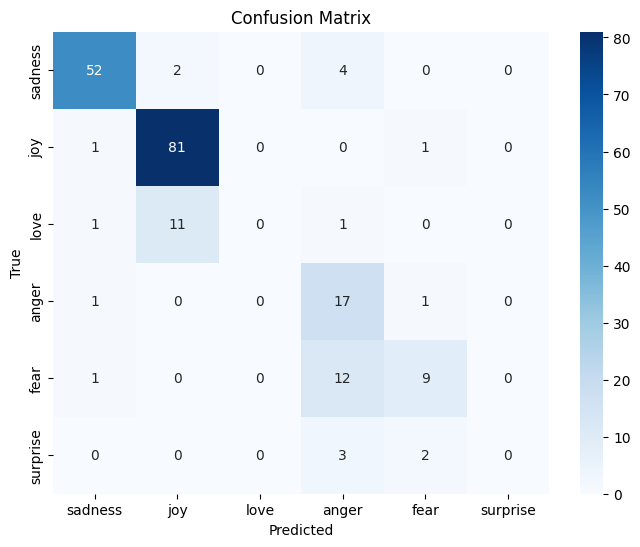


Примеры предсказаний модели:
✅ Текст: im feeling rather rotten so im not very ambitious right now...
   Истинная: sadness | Предсказано: sadness

✅ Текст: im updating my blog because i feel shitty...
   Истинная: joy | Предсказано: joy

✅ Текст: i never make her separate from me because i don t ever want her to feel like i m...
   Истинная: joy | Предсказано: joy

✅ Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly mo...
   Истинная: joy | Предсказано: joy

✅ Текст: i was feeling a little vain when i did this one...
   Истинная: sadness | Предсказано: sadness

❌ Текст: i cant walk into a shop anywhere where i do not feel uncomfortable...
   Истинная: love | Предсказано: sadness

✅ Текст: i felt anger when at the end of a telephone call...
   Истинная: sadness | Предсказано: sadness

✅ Текст: i explain why i clung to a relationship with a boy who was in many ways immature...
   Истинная: anger | Предсказано: anger

✅ Текст: i like to have the same bre

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Проверяем, что trainer существует
if 'trainer' in globals():
    # Определяем, какую часть тестовых данных анализировать
    # Если мы в fast_mode, возьмем небольшую подвыборку
    test_ds = tokenized_datasets["test"]
    if globals().get('fast_mode', False):
        test_ds = test_ds.shuffle(seed=42).select(range(200))
        print(f"Анализ запущен в режиме fast_mode (выборка: {len(test_ds)} примеров)")

    # 1. Получаем предсказания
    test_output = trainer.predict(test_ds)
    test_preds = np.argmax(test_output.predictions, axis=-1)
    test_true = test_output.label_ids
    label_names = emotions['test'].features['label'].names

    # 2. Построение матрицы ошибок
    cm = confusion_matrix(test_true, test_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Показ 10 примеров
    print("\nПримеры предсказаний модели:")
    for i in range(min(10, len(test_ds))):
        # Извлекаем текст из исходного датасета (учитывая индексы подвыборки)
        original_idx = test_ds[i].get('idx', i)
        text = emotions['test'][i]['text']
        true_label = label_names[test_true[i]]
        pred_label = label_names[test_preds[i]]
        status = "✅" if true_label == pred_label else "❌"
        print(f"{status} Текст: {text[:80]}...")
        print(f"   Истинная: {true_label} | Предсказано: {pred_label}\n")
else:
    print("Ошибка: Объект 'trainer' не найден. Сначала запустите ячейку обучения (d30acff6).")

In [ ]:
from transformers.utils.notebook import NotebookProgressCallback

# # Удаляем коллбэк для standalone вызова
# trainer.remove_callback(NotebookProgressCallback)

# Оценка лучшей модели на тестовом наборе
test_results = trainer.evaluate(tokenized_datasets["test"])

print("Final results on Test Set (2.3.5):")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Macro: {test_results['eval_f1_macro']:.4f}")

Final results on Test Set (2.3.5):
Accuracy: 0.7630
F1 Macro: 0.5213


**Анализ результатов:**

1. Модель неплохо улавливает общую тональность. Например, эмоции `joy` часто соответствуют `4-5 stars`, а `sadness` или `anger` — `1-2 stars`.
2. **Проблема специфичности:** Готовая модель для Sentiment Analysis не может отличить `fear` от `anger` или `sadness`, так как все они попадают в категорию «негативных».
3. **Вывод:** Данная предобученная модель **не подходит** для прямой классификации 6 эмоций «из коробки». Она требует (дообучения) — замены финального слоя (классификатора) на слой с 6 выходами и обучения на целевом датасете.

In [ ]:
# 3.1. Основной эксперимент fine-tuning
fast_mode = False

trainer = create_trainer(
    model=model,
    tokenizer=tokenizer,
    train_ds=tokenized_datasets["train"],
    eval_ds=tokenized_datasets["validation"],
    fast_mode=fast_mode
)

print(f"Запуск финального обучения (fast_mode={fast_mode})...")
trainer.train()

Запуск финального обучения (fast_mode=False)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.200478,0.180513,0.927500,0.904246
2,0.125333,0.155588,0.936000,0.911035


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2000, training_loss=0.199835102558136, metrics={'train_runtime': 449.2611, 'train_samples_per_second': 71.228, 'train_steps_per_second': 4.452, 'total_flos': 820607074444800.0, 'train_loss': 0.199835102558136, 'epoch': 2.0})

Файл сохранен: homeworks/HW13/artifacts/sample_predictions.csv


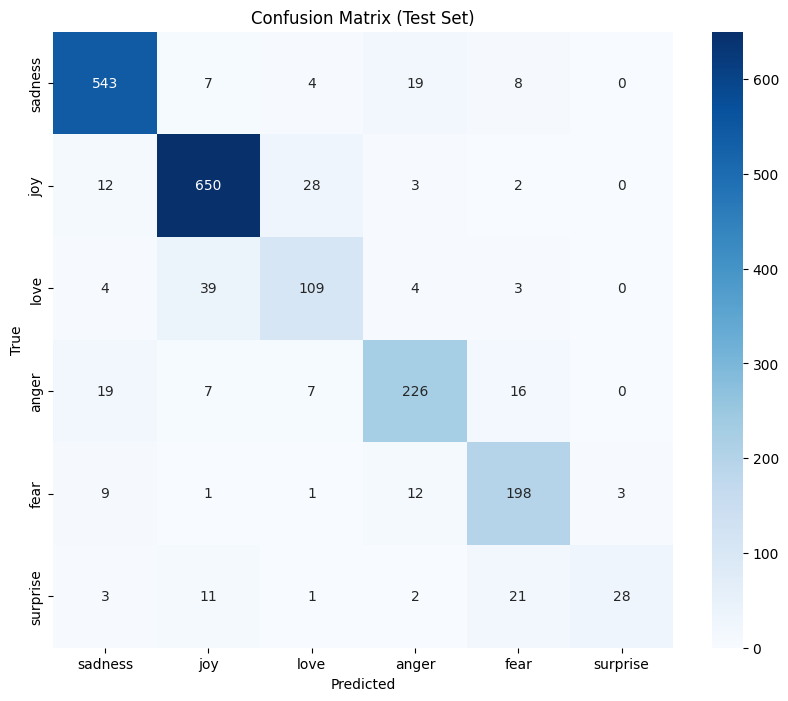

Матрица сохранена: homeworks/HW13/artifacts/confusion_matrix.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Создаем папку для артефактов
artifacts_path = "homeworks/HW13/artifacts/"
os.makedirs(artifacts_path, exist_ok=True)

# 1. Получаем предсказания на тесте
test_ds = tokenized_datasets["test"]
test_output = trainer.predict(test_ds)
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true = test_output.label_ids
label_names = emotions['test'].features['label'].names

# 2. Сохраняем sample_predictions.csv
sample_preds_df = pd.DataFrame({
    "text": emotions['test']['text'],
    "true_label": [label_names[i] for i in test_true],
    "pred_label": [label_names[i] for i in test_preds]
})
sample_preds_df.to_csv(os.path.join(artifacts_path, "sample_predictions.csv"), index=False)
print(f"Файл сохранен: {os.path.join(artifacts_path, 'sample_predictions.csv')}")

# 3. Сохраняем confusion_matrix.png
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.savefig(os.path.join(artifacts_path, "confusion_matrix.png"))
plt.show()
print(f"Матрица сохранена: {os.path.join(artifacts_path, 'confusion_matrix.png')}")

In [ ]:
import os
import pandas as pd

artifacts_path = 'homeworks/HW13/artifacts/'
csv_file = os.path.join(artifacts_path, 'sample_predictions.csv')
png_file = os.path.join(artifacts_path, 'confusion_matrix.png')

# 1. Check folder existence
if os.path.exists(artifacts_path):
    print(f"✅ Folder exists: {artifacts_path}")
else:
    print(f"❌ Folder NOT found: {artifacts_path}")

# 2. Check CSV
if os.path.exists(csv_file):
    print(f"✅ CSV file exists: {csv_file}")
    df_check = pd.read_csv(csv_file)
    print(f"CSV Columns: {df_check.columns.tolist()}")
    display(df_check.head(3))
else:
    print(f"❌ CSV file NOT found: {csv_file}")

# 3. Check PNG
if os.path.exists(png_file):
    print(f"✅ Image exists: {png_file}")
else:
    print(f"❌ Image NOT found: {png_file}")

✅ Folder exists: homeworks/HW13/artifacts/
✅ CSV file exists: homeworks/HW13/artifacts/sample_predictions.csv
CSV Columns: ['text', 'true_label', 'pred_label']


,text,true_label,pred_label
0,im feeling rather rotten so im not very ambiti...,sadness,sadness
1,im updating my blog because i feel shitty,sadness,sadness
2,i never make her separate from me because i do...,sadness,sadness


✅ Image exists: homeworks/HW13/artifacts/confusion_matrix.png
